In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
url = ('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv')

In [65]:
url = 'https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [66]:
df.columns


Index(['Unnamed: 0', 'rank', 'discipline', 'yrs.since.phd', 'yrs.service',
       'sex', 'salary'],
      dtype='object')

In [67]:
## data exploration - mean/median of all salaries,

df['salary'].describe()

,salary
count,397.000000
mean,113706.458438
std,30289.038695
min,57800.000000
25%,91000.000000
50%,107300.000000
75%,134185.000000
max,231545.000000


In [68]:
## Median salary by gender

df.groupby('sex')['salary'].agg(['mean', 'median'])

,mean,median
sex,,
Female,101002.410256,103750.0
Male,115090.418994,108043.0


In [69]:
## Median salary by rank/title
df.groupby('rank')['salary'].agg(['count', 'mean', 'median'])


,count,mean,median
rank,,,
AssocProf,64,93876.437500,95626.5
AsstProf,67,80775.985075,79800.0
Prof,266,126772.109023,123321.5


In [70]:
## Median salary by gender and/or rank/title

df.groupby(['sex', 'rank'])['salary'].agg(['count', 'mean', 'median'])

count           mean    median
sex    rank                                     
Female AssocProf     10   88512.800000   90556.5
       AsstProf      11   78049.909091   77000.0
       Prof          18  121967.611111  120257.5
Male   AssocProf     54   94869.703704   95626.5
       AsstProf      56   81311.464286   80182.0
       Prof         248  127120.822581  123996.0

In [89]:
## Data wrangling - renaming columns,

df = df.rename(columns={
    'yrs.since.phd': 'years_since_phd',
    'yrs.service': 'years_service',
    'sex': 'gender'})
df.head()

,Unnamed: 0,rank,discipline,years_since_phd,years_service,gender,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [74]:
## Data wrangling - subsetting columns

df[['rank', 'gender', 'salary']].head()

,rank,gender,salary
0,Prof,Male,139750
1,Prof,Male,173200
2,AsstProf,Male,79750
3,Prof,Male,115000
4,Prof,Male,141500


In [76]:
## Data wrangling - handling missing data

df.isnull().sum()

,0
Unnamed: 0,0
rank,0
discipline,0
years_since_phd,0
years_service,0
gender,0
salary,0


In [78]:
df.dtypes

,0
Unnamed: 0,int64
rank,object
discipline,object
years_since_phd,int64
years_service,int64
gender,object
salary,int64


Text(0, 0.5, 'Number')

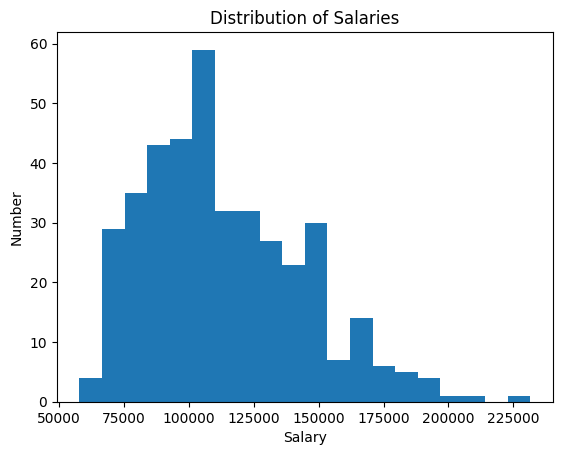

In [86]:
## Data visualizations

df['salary'].plot(kind='hist',bins=20, title='Distribution of Salaries')

plt.xlabel('Salary')
plt.ylabel('Number')


Text(0, 0.5, 'Average Salary')

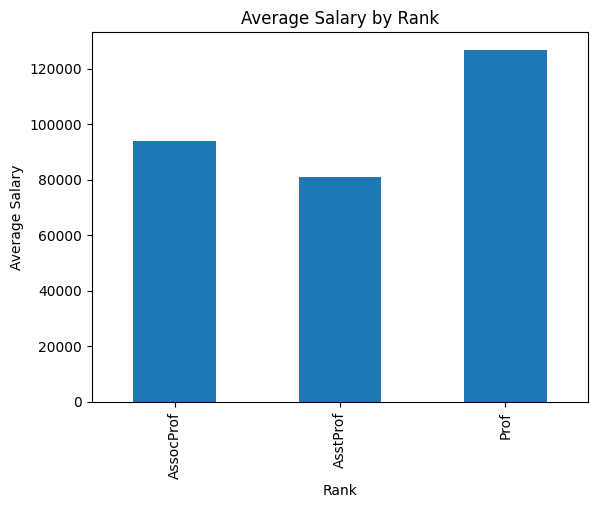

In [87]:
df.groupby('rank')['salary'].mean().plot(kind='bar',title='Average Salary by Rank')

plt.xlabel('Rank')
plt.ylabel('Average Salary')


Conclusions

-Professors have the highest salaries for both genders. Female professors have a median salary of $120,257.50, while male professors have a median of $123,996.

-Assistant Professors have the lowest salaries for both genders. The median is $77,000 for females and $80,182 for males.

-For every academic rank in this dataset, the male mean and median salaries are higher than the corresponding female figures.

-The difference is relatively small for Assistant Professors, while it is more noticeable among Professors.

-Academic rank appears to be strongly associated with salary: moving from Assistant Professor to Associate Professor to Professor corresponds to higher mean and median salaries for both genders.

-The dataset contains substantially more male observations, particularly among Professors (248 males vs. 18 females), so the gender comparisons should be interpreted in the context of these different group sizes.